# Value at Risk (VaR) — Hướng dẫn cho người mới

Notebook này giải thích **VaR** là gì, cách tính, và ứng dụng thực tế trong Trading/Investing.

**Ví dụ thực tế**: Cổ phiếu **FPT** trên sàn HOSE, dữ liệu từ CafeF.

## 1. VaR là gì?

**Value at Risk (VaR)** trả lời câu hỏi:

> Trong điều kiện thị trường bình thường, tôi có thể **lỗ tối đa bao nhiêu** trong một khoảng thời gian, với một mức **độ tin cậy** nhất định?

### Ví dụ
- Danh mục: **1 tỷ VNĐ** cổ phiếu FPT
- VaR 1 ngày, 95% = **2.5%**

Nghĩa là:
> Có **95% xác suất** danh mục sẽ **không lỗ quá 2.5%** (tức **25 triệu VNĐ**) trong 1 ngày.

### Lưu ý quan trọng
VaR **không phải**:
- Mức lỗ tối đa có thể xảy ra
- Một sự đảm bảo

VaR là **phân vị (quantile)** của phân phối lợi nhuận — một ngưỡng cảnh báo rủi ro.

## 2. Ba khái niệm cốt lõi

| Khái niệm | Ý nghĩa | Ví dụ |
|-----------|---------|-------|
| **Volatility** (Biến động) | Giá dao động trung bình bao nhiêu | Std dev = 2% / ngày |
| **VaR** | Ngưỡng lỗ ở mức tin cậy chọn trước | 95% VaR = -2.5% |
| **Expected Shortfall (ES)** | Lỗ trung bình khi vượt qua VaR | ES = -3.8% |

### Best Practice
1. Dùng **Historical VaR** trước (không giả định phân phối chuẩn)
2. Kết hợp **Expected Shortfall** để biết "nếu xấu thì xấu đến đâu"
3. **Backtest** để kiểm tra mô hình
4. Dùng **rolling window** để theo dõi rủi ro thay đổi theo thời gian

## 3. Lấy dữ liệu thực — Cổ phiếu FPT từ CafeF

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import zipfile, io, requests

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# --- Download CafeF feather file ---
url = 'https://github.com/algo-stocks/data/releases/download/v2.0/CafeF.feather.zip'
print('Đang tải dữ liệu CafeF...')
r = requests.get(url)
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    fname = [f for f in z.namelist() if f.endswith('.feather')][0]
    with z.open(fname) as f:
        market = pd.read_feather(f)

print(f'Loaded: {market["ticker"].nunique()} mã, {len(market):,} dòng')
print(f'Từ {market["date"].min().date()} đến {market["date"].max().date()}')

Đang tải dữ liệu CafeF...
Loaded: 3638 mã, 3,224,935 dòng
Từ 2000-07-28 đến 2026-03-20


In [ ]:
# --- Lọc FPT, tính daily returns ---
fpt = (
    market[market['ticker'] == 'FPT']
    .sort_values('date')
    .set_index('date')
    .copy()
)
fpt['returns'] = fpt['close'].pct_change()
fpt = fpt.dropna(subset=['returns'])

print(f'FPT: {len(fpt)} phiên, từ {fpt.index.min().date()} đến {fpt.index.max().date()}')
fpt[['close', 'volume', 'returns']].tail()

FPT: 4794 phiên, từ 2006-12-14 đến 2026-03-20


,close,volume,returns
date,,,
2026-03-16,78.2000,8662000,0.0156
2026-03-17,79.4000,9218800,0.0153
2026-03-18,78.6000,6352700,-0.0101
2026-03-19,76.8000,11602900,-0.0229
2026-03-20,74.6000,21423700,-0.0286


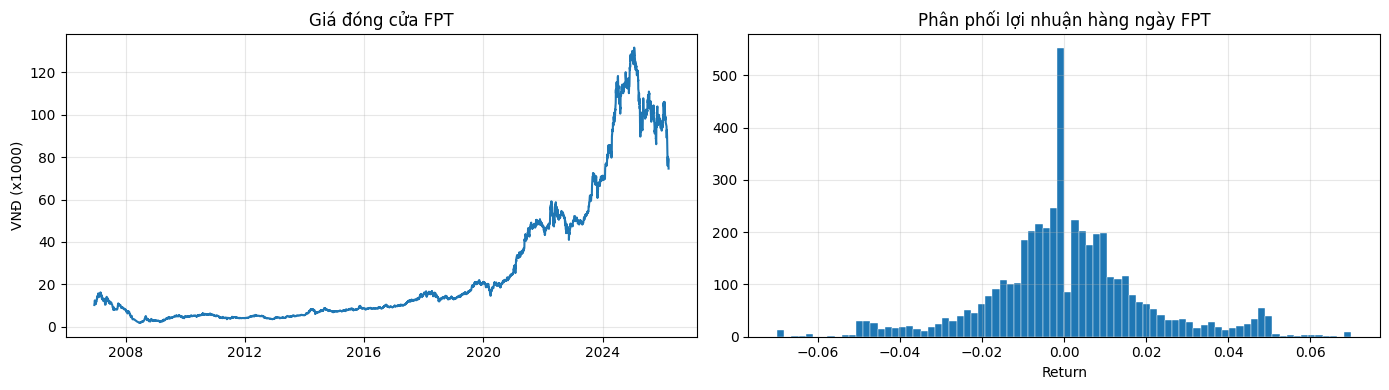

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(fpt.index, fpt['close'])
axes[0].set_title('Giá đóng cửa FPT')
axes[0].set_ylabel('VNĐ (x1000)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(fpt['returns'], bins=80, edgecolor='white', linewidth=0.3)
axes[1].set_title('Phân phối lợi nhuận hàng ngày FPT')
axes[1].set_xlabel('Return')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Historical VaR (Phương pháp lịch sử)

Cách đơn giản nhất: lấy **phân vị thứ 5** (cho 95% confidence) từ dữ liệu lợi nhuận thực tế.

**Ưu điểm**: Không giả định phân phối, phản ánh đúng thực tế.

**Nhược điểm**: Phụ thuộc vào cửa sổ dữ liệu đã chọn.

In [ ]:
confidence = 0.95
alpha = 1 - confidence

var_hist = np.percentile(fpt['returns'], alpha * 100)

portfolio = 1_000_000_000  # 1 tỷ VNĐ
print(f'Historical VaR (95%, 1 ngày): {var_hist:.4%}')
print(f'Với danh mục {portfolio/1e9:.0f} tỷ VNĐ → Lỗ tối đa ước tính: {abs(var_hist) * portfolio:,.0f} VNĐ')

Historical VaR (95%, 1 ngày): -3.1881%
Với danh mục 1 tỷ VNĐ → Lỗ tối đa ước tính: 31,881,123 VNĐ


## 5. Backtesting — Kiểm tra VaR có đúng không?

Với VaR 95%, ta kỳ vọng khoảng **5% số phiên** sẽ vi phạm (lỗ vượt ngưỡng).

- Vi phạm quá nhiều → VaR quá lạc quan
- Vi phạm quá ít → VaR quá thận trọng

In [ ]:
violations = fpt['returns'] < var_hist
violation_rate = violations.mean()

print(f'Tỷ lệ vi phạm kỳ vọng: {alpha:.2%}')
print(f'Tỷ lệ vi phạm thực tế: {violation_rate:.2%}')
print(f'Số phiên vi phạm: {violations.sum()} / {len(fpt)}')

Tỷ lệ vi phạm kỳ vọng: 5.00%
Tỷ lệ vi phạm thực tế: 5.01%
Số phiên vi phạm: 240 / 4794


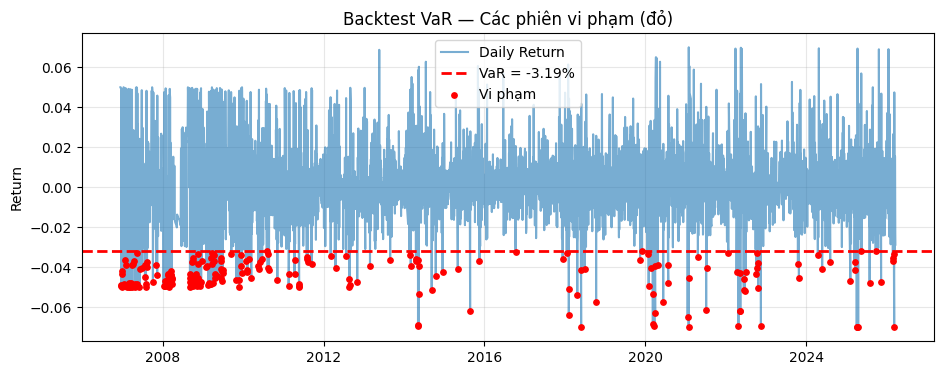

In [ ]:
plt.plot(fpt.index, fpt['returns'], alpha=0.6, label='Daily Return')
plt.axhline(var_hist, color='red', ls='--', lw=2, label=f'VaR = {var_hist:.2%}')
plt.scatter(fpt.index[violations], fpt.loc[violations, 'returns'],
            color='red', s=15, zorder=5, label='Vi phạm')
plt.title('Backtest VaR — Các phiên vi phạm (đỏ)')
plt.ylabel('Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Expected Shortfall (ES) — Lỗ trung bình khi vượt VaR

VaR cho biết **ngưỡng**. Nhưng nếu vượt ngưỡng, lỗ trung bình là bao nhiêu?

Ví dụ: VaR = -3%, nhưng ES = -4.5% → khi lỗ vượt 3%, trung bình sẽ lỗ khoảng 4.5%.

In [ ]:
es_hist = fpt.loc[fpt['returns'] < var_hist, 'returns'].mean()

print(f'Expected Shortfall (95%, 1 ngày): {es_hist:.4%}')
print(f'Khi lỗ vượt VaR, trung bình lỗ: {abs(es_hist) * portfolio:,.0f} VNĐ')

Expected Shortfall (95%, 1 ngày): -4.4934%
Khi lỗ vượt VaR, trung bình lỗ: 44,934,110 VNĐ


## 7. Rolling VaR — Theo dõi rủi ro thay đổi theo thời gian

Tính VaR trên cửa sổ trượt (252 phiên ≈ 1 năm) để thấy rủi ro tăng/giảm.

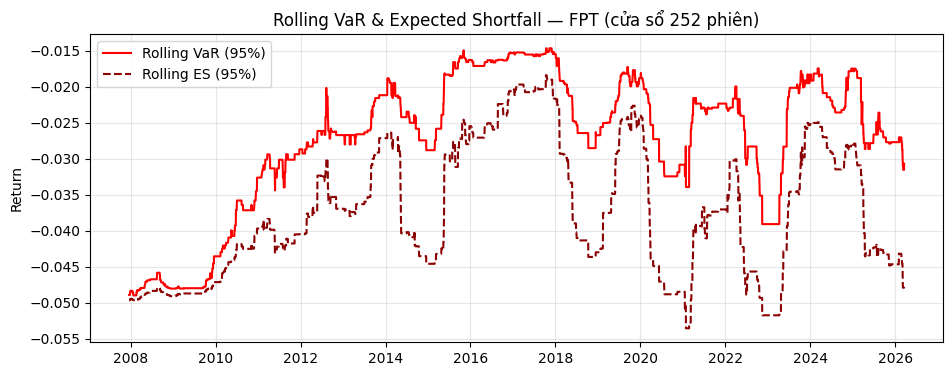

In [ ]:
window = 252
fpt['rolling_var'] = fpt['returns'].rolling(window).quantile(alpha)
fpt['rolling_es'] = fpt['returns'].rolling(window).apply(
    lambda x: x[x < np.quantile(x, alpha)].mean(), raw=False
)

plt.plot(fpt.index, fpt['rolling_var'], label='Rolling VaR (95%)', color='red')
plt.plot(fpt.index, fpt['rolling_es'], label='Rolling ES (95%)', color='darkred', ls='--')
plt.title('Rolling VaR & Expected Shortfall — FPT (cửa sổ 252 phiên)')
plt.ylabel('Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Ứng dụng — Position Sizing

Nếu tài khoản = 1 tỷ VNĐ, rủi ro tối đa/ngày = 1% (10 triệu), và VaR của FPT = 3.19%:

$$\text{Vị thế tối đa} = \frac{\text{Ngân sách rủi ro}}{|VaR|} = \frac{10\text{M}}{3.19\%} = 314\text{M VNĐ}$$

**Tip**: Nếu rolling VaR tăng → giảm vị thế. VaR cũng giúp so sánh rủi ro giữa các mã.

In [ ]:
# Ví dụ: Position Sizing với FPT
account = 1_000_000_000  # 1 tỷ
risk_budget_pct = 0.01   # 1% = 10 triệu/ngày
risk_budget = account * risk_budget_pct
asset_var = abs(var_hist)

max_position = risk_budget / asset_var

print(f'Tài khoản: {account/1e9:.0f} tỷ VNĐ')
print(f'Ngân sách rủi ro: {risk_budget_pct:.0%} = {risk_budget/1e6:.0f} triệu/ngày')
print(f'VaR FPT: {asset_var:.2%}')
print(f'→ Vị thế tối đa FPT: {max_position/1e6:,.0f} triệu VNĐ')

Tài khoản: 1 tỷ VNĐ
Ngân sách rủi ro: 1% = 10 triệu/ngày
VaR FPT: 3.19%
→ Vị thế tối đa FPT: 314 triệu VNĐ


## 9. Hạn chế của VaR

| Hạn chế | Giải pháp |
|---------|----------|
| Không cho biết lỗ vượt ngưỡng bao nhiêu | Dùng thêm **Expected Shortfall** |
| Thất bại khi thị trường thay đổi cấu trúc | Dùng **rolling window** ngắn hơn |
| Phụ thuộc cửa sổ dữ liệu | Kiểm tra với nhiều cửa sổ khác nhau |

## 10. Tóm tắt

### Quy trình thực hành
1. Tính **Historical VaR** trên dữ liệu thực
2. **Backtest** — kiểm tra tỷ lệ vi phạm ≈ 5%
3. Tính **Expected Shortfall** để biết tail risk
4. Dùng **rolling window** theo dõi rủi ro thay đổi
5. Nếu VaR tăng → giảm vị thế

### Bài tập tự làm
1. Đổi confidence từ 95% sang 99%
2. Thay FPT bằng mã khác (VCB, HPG, VNM)
3. So sánh VaR 1 ngày vs 5 ngày vs 20 ngày
4. Viết rule: nếu rolling VaR > ngưỡng → giảm 50% vị thế

---

## Nâng cao: Các phương pháp VaR khác

Ngoài Historical VaR, còn có 2 phương pháp phổ biến khác. Cả hai đều **giả định phân phối** nên có thể đánh giá thấp rủi ro khi thị trường có fat tails.

### Parametric VaR (Phương pháp tham số)
Giả định returns ~ Normal: $VaR = \mu + z_\alpha \times \sigma$

### Monte Carlo VaR
Mô phỏng hàng trăm ngàn kịch bản, rồi lấy phân vị. Linh hoạt hơn nhưng chậm hơn.

In [ ]:
mu = fpt['returns'].mean()
sigma = fpt['returns'].std(ddof=1)
z = norm.ppf(alpha)

# Parametric VaR
var_param = mu + z * sigma
print(f'Parametric VaR (95%, 1 ngày): {var_param:.4%}')

# Monte Carlo VaR
np.random.seed(42)
sim_returns = np.random.normal(loc=mu, scale=sigma, size=100_000)
var_mc = np.percentile(sim_returns, alpha * 100)
print(f'Monte Carlo VaR (95%, 1 ngày): {var_mc:.4%}')

# So sánh
comparison = pd.DataFrame({
    'Phương pháp': ['Historical', 'Parametric', 'Monte Carlo'],
    'VaR (%)': [var_hist * 100, var_param * 100, var_mc * 100],
    'Lỗ ước tính (triệu VNĐ)': [
        abs(var_hist) * portfolio / 1e6,
        abs(var_param) * portfolio / 1e6,
        abs(var_mc) * portfolio / 1e6
    ]
})
comparison

Parametric VaR (95%, 1 ngày): -3.1269%
Monte Carlo VaR (95%, 1 ngày): -3.1242%


,Phương pháp,VaR (%),Lỗ ước tính (triệu VNĐ)
0,Historical,-3.1881,31.8811
1,Parametric,-3.1269,31.2685
2,Monte Carlo,-3.1242,31.2421
